# Satellite Toolkit Examples

Examples from the official docs of the Python satellite / astronomy stack installed in this project:

| Package | Purpose |
|---|---|
| [`sgp4`](https://pypi.org/project/sgp4/) | Raw SGP4/SDP4 orbit propagation from TLEs (the low-level engine) |
| [`skyfield`](https://rhodesmill.org/skyfield/) | High-level astronomy: satellite positions, observer passes, ground tracks |
| [`astropy`](https://docs.astropy.org/) | Units, time scales, and reference-frame transformations (TEME → ITRS) |
| [`Pillow`](https://pillow.readthedocs.io/) | Basic image loading and manipulation |
| [`scikit-image`](https://scikit-image.org/) | Scientific image processing (edge detection, filters) |

> **Note on poliastro:** `poliastro` was archived in 2023 and its last release only supports
> Python ≤ 3.10 (this project uses 3.13). Its maintained fork `hapsira` pins `matplotlib < 3.8`,
> which conflicts with this project. `astropy` — the foundation both were built on — is installed
> instead and covers the coordinate/units functionality.

The ISS TLE below was fetched from [Celestrak](https://celestrak.org) on 2026-07-02
(epoch 2026-07-01). TLEs lose accuracy after ~2 weeks, so refresh it for real work.

In [1]:
# Fresh ISS TLE (fetched 2026-07-02 from Celestrak)
TLE_NAME = 'ISS (ZARYA)'
TLE_LINE1 = '1 25544U 98067A   26182.50817465  .00006185  00000+0  11827-3 0  9996'
TLE_LINE2 = '2 25544  51.6311 229.1989 0004224 255.0896 104.9625 15.49503254573972'

## 1. `sgp4` — raw TLE propagation

The canonical example from the [python-sgp4 README](https://pypi.org/project/sgp4/):
parse a TLE with `Satrec.twoline2rv()` and propagate to a Julian date with `.sgp4()`.
Positions/velocities are returned in the idiosyncratic **TEME** (True Equator, Mean Equinox)
inertial frame, in km and km/s.

In [2]:
from sgp4.api import Satrec, jday

satellite = Satrec.twoline2rv(TLE_LINE1, TLE_LINE2)

jd, fr = jday(2026, 7, 2, 12, 0, 0)   # 2026-07-02 12:00:00 UTC
e, r, v = satellite.sgp4(jd, fr)

print('error code:', e)               # 0 = success
print('position (TEME, km):  ', r)
print('velocity (TEME, km/s):', v)

error code: 0
position (TEME, km):   (5552.677700977193, 1349.7846899168378, 3674.0150123098483)
velocity (TEME, km/s): (1.3852684546999887, 6.155302416814028, -4.347049314499124)


In [3]:
# Batch propagation over an array of times with sgp4's vectorized API
import numpy as np
from sgp4.api import SatrecArray

jd_arr = np.array([jd, jd, jd])
fr_arr = fr + np.array([0.0, 45.0, 90.0]) / 1440.0   # +0, +45, +90 minutes

e_arr, r_arr, v_arr = SatrecArray([satellite]).sgp4(jd_arr, fr_arr)
print('error codes:', e_arr.ravel())
print('positions (km):')
print(r_arr[0])

error codes: [0 0 0]
positions (km):
[[ 5552.67770098  1349.78468992  3674.01501231]
 [-5412.28218466  -794.55602874 -4036.84609702]
 [ 5212.70251668   241.79611172  4348.85957164]]


## 2. `skyfield` — high-level satellite work

From the Skyfield [Earth Satellites](https://rhodesmill.org/skyfield/earth-satellites.html)
documentation: build an `EarthSatellite`, check its epoch, and get the sub-satellite point
(latitude/longitude on the WGS84 ellipsoid).

In [4]:
from skyfield.api import load, wgs84, EarthSatellite

ts = load.timescale()
iss = EarthSatellite(TLE_LINE1, TLE_LINE2, TLE_NAME, ts)
print('TLE epoch:', iss.epoch.utc_iso())

# Where is the ISS right now (well, at a fixed moment)?
t = ts.utc(2026, 7, 2, 12, 0, 0)
geocentric = iss.at(t)

lat, lon = wgs84.latlon_of(geocentric)
height = wgs84.height_of(geocentric)
print(f'Subpoint: {lat.degrees:.4f} deg lat, {lon.degrees:.4f} deg lon')
print(f'Altitude: {height.km:.1f} km above WGS84 ellipsoid')

TLE epoch: 2026-07-01T12:11:46Z
Subpoint: 32.9031 deg lat, -86.8789 deg lon
Altitude: 421.7 km above WGS84 ellipsoid


### Rise / culminate / set events over an observer

`find_events()` returns when the satellite rises above, culminates over, and sets below a
given altitude for an observer — here, passes above 30° over Bangkok during one day.

In [5]:
bangkok = wgs84.latlon(+13.7563, +100.5018)

t0 = ts.utc(2026, 7, 2)
t1 = ts.utc(2026, 7, 3)
times, events = iss.find_events(bangkok, t0, t1, altitude_degrees=30.0)

event_names = 'rise above 30 deg', 'culminate', 'set below 30 deg'
for ti, event in zip(times, events):
    print(ti.utc_strftime('%Y %b %d %H:%M:%S'), event_names[event])

2026 Jul 02 01:16:06 rise above 30 deg
2026 Jul 02 01:17:18 culminate
2026 Jul 02 01:18:30 set below 30 deg
2026 Jul 02 14:34:49 rise above 30 deg
2026 Jul 02 14:35:55 culminate
2026 Jul 02 14:37:01 set below 30 deg


### Topocentric position: altitude, azimuth, distance

Subtracting the observer from the satellite gives the position *relative to the observer*,
from which `.altaz()` yields where to look in the sky.

In [6]:
difference = iss - bangkok
topocentric = difference.at(t)

alt, az, distance = topocentric.altaz()
print(f'Altitude: {alt.degrees:8.2f} deg')
print(f'Azimuth:  {az.degrees:8.2f} deg')
print(f'Distance: {distance.km:8.0f} km')

Altitude:   -65.66 deg
Azimuth:      8.48 deg
Distance:    12082 km


### Ground track for one orbit

Skyfield accepts arrays of times, so a whole orbit (~93 minutes for the ISS) can be
computed in one vectorized call.

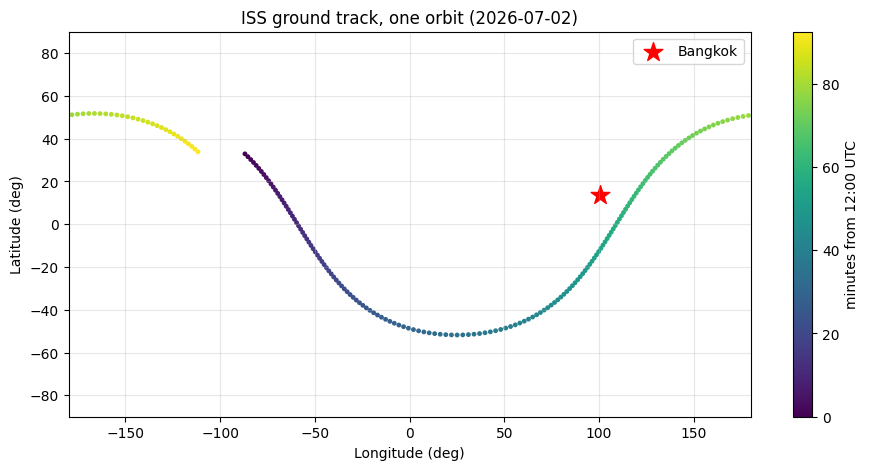

In [7]:
import matplotlib.pyplot as plt

minutes = np.arange(0, 93, 0.5)
t_orbit = ts.utc(2026, 7, 2, 12, minutes)
lat, lon = wgs84.latlon_of(iss.at(t_orbit))

fig, ax = plt.subplots(figsize=(11, 5))
sc = ax.scatter(lon.degrees, lat.degrees, s=6, c=minutes, cmap='viridis')
ax.scatter([100.5018], [13.7563], marker='*', s=200, color='red', label='Bangkok')
fig.colorbar(sc, label='minutes from 12:00 UTC')
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude (deg)'); ax.set_ylabel('Latitude (deg)')
ax.set_title('ISS ground track, one orbit (2026-07-02)')
ax.grid(alpha=0.3); ax.legend()
plt.show()

## 3. `astropy` — TEME to ITRS frame conversion

From the astropy docs, [*Working with Earth Satellites*](https://docs.astropy.org/en/stable/coordinates/satellites.html):
take the raw TEME state vector from `sgp4` and transform it into the Earth-fixed **ITRS**
frame, from which a geodetic location (lat/lon/height) falls out directly.

In [8]:
from astropy import units as u
from astropy.time import Time
from astropy.utils import iers
iers.conf.auto_download = False   # use the bundled astropy-iers-data tables (offline-friendly)
from astropy.coordinates import TEME, ITRS, CartesianDifferential, CartesianRepresentation

t_ap = Time(satellite.jdsatepoch, satellite.jdsatepochF, format='jd')
error_code, teme_p, teme_v = satellite.sgp4(t_ap.jd1, t_ap.jd2)  # position at TLE epoch
assert error_code == 0

teme_p = CartesianRepresentation(teme_p * u.km)
teme_v = CartesianDifferential(teme_v * u.km / u.s)
teme = TEME(teme_p.with_differentials(teme_v), obstime=t_ap)

itrs_geo = teme.transform_to(ITRS(obstime=t_ap))
location = itrs_geo.earth_location
print(location.geodetic)

GeodeticLocation(lon=<Longitude 126.6920619 deg>, lat=<Latitude 0.00012468 deg>, height=<Quantity 419.66079737 km>)


In [9]:
# astropy units make orbital arithmetic self-documenting:
# orbital period straight from the TLE mean motion (rad/min)
n = satellite.no_kozai * u.rad / u.min
period = (2 * np.pi * u.rad / n).to(u.min)
print(f'ISS orbital period: {period:.2f}')

# ...and Kepler's third law gives the semi-major axis
GM_earth = 398600.4418 * u.km**3 / u.s**2
a = (GM_earth / (n / u.rad)**2)**(1 / 3)
print(f'Semi-major axis:    {a.to(u.km):.1f}')
print(f'Mean altitude:      {(a - 6378.137 * u.km).to(u.km):.1f}')

ISS orbital period: 92.93 min
Semi-major axis:    6796.3 km
Mean altitude:      418.2 km


## 4. `Pillow` — basic image handling

From the [Pillow tutorial](https://pillow.readthedocs.io/en/stable/handbook/tutorial.html):
open an image, inspect its attributes, then rotate and filter. We use scikit-image's
bundled `moon` sample (space-themed!) converted to a PIL `Image`.

size=(512, 512), mode=L


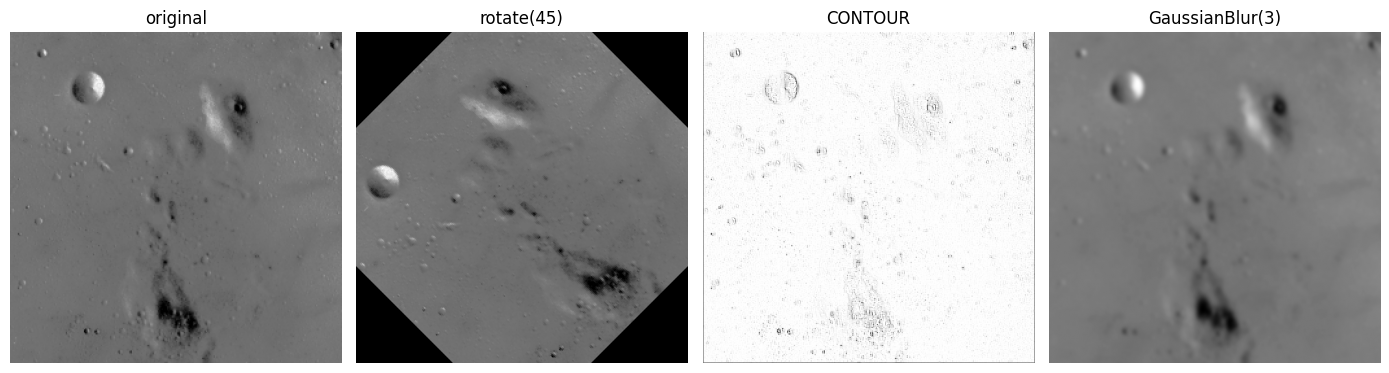

In [10]:
from PIL import Image, ImageFilter
from skimage import data

moon = Image.fromarray(data.moon())
print(f'size={moon.size}, mode={moon.mode}')

rotated  = moon.rotate(45)                    # rotate 45 degrees counter-clockwise
contour  = moon.filter(ImageFilter.CONTOUR)   # built-in convolution filter
blurred  = moon.filter(ImageFilter.GaussianBlur(radius=3))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, im, title in zip(axes, [moon, rotated, contour, blurred],
                         ['original', 'rotate(45)', 'CONTOUR', 'GaussianBlur(3)']):
    ax.imshow(im, cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

## 5. `scikit-image` — Canny edge detection

The classic example from the scikit-image docs
([Canny edge detector](https://scikit-image.org/docs/stable/auto_examples/edges/plot_canny.html)):
the `sigma` parameter of the Gaussian pre-filter controls how much detail survives.

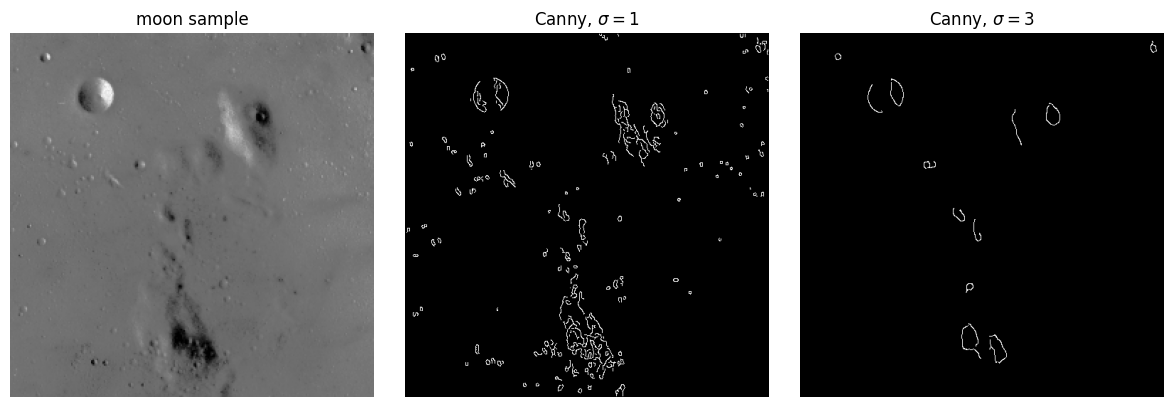

In [11]:
from skimage import feature

image = data.moon()
edges1 = feature.canny(image, sigma=1)
edges2 = feature.canny(image, sigma=3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap='gray');  axes[0].set_title('moon sample')
axes[1].imshow(edges1, cmap='gray'); axes[1].set_title(r'Canny, $\sigma=1$')
axes[2].imshow(edges2, cmap='gray'); axes[2].set_title(r'Canny, $\sigma=3$')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()